Notebook to compare the dimension vs the CRPS for different values of the horizons

In [1]:
%load_ext autoreload
%autoreload 2

import xarray as xr
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import skdim
from scipy.stats import linregress

from utils.CRPS import comp_CRPS_clim_horizons, comp_CRPS_ana_horizons
from utils.analogues_functions import (find_analogues, loo_procedure, separate_trajectories, 
compute_diffs, compute_mae_mad, compute_CRPSana, compute_CRPSclim, compute_mae_monte_carlo, compute_CRPSclim_fast)
from utils.preprocess import preprocess_data

# Load data and compute CRPS

In [2]:
# load data
data_folder = 'data/'

max_horizon = 5 # in days
subsampling = 7 # in days
data_per_day = 2

# targets are the points for which we compute the CRPS_clim, and ind_tar are their indices in pcs_norm
pcs_norm, ind_tar, horizons = preprocess_data(data_folder, subsampling, max_horizon)

In [12]:
# compute CRPS clim
window_clim = 30 # in days
CRPS_clim = comp_CRPS_clim_horizons(pcs_norm, ind_tar, horizons, window_clim)

100%|██████████████████████████████████████| 2336/2336 [00:19<00:00, 117.51it/s]


In [13]:
# compute CRPS_ana
Kvalues = [10, 20, 50, 100]
CRPS_ana = comp_CRPS_ana_horizons(pcs_norm, ind_tar, horizons, Kvalues)

100%|█████████████████████████████████████████████| 4/4 [00:15<00:00,  3.77s/it]


# CRPS_clim vs CRPS_ana

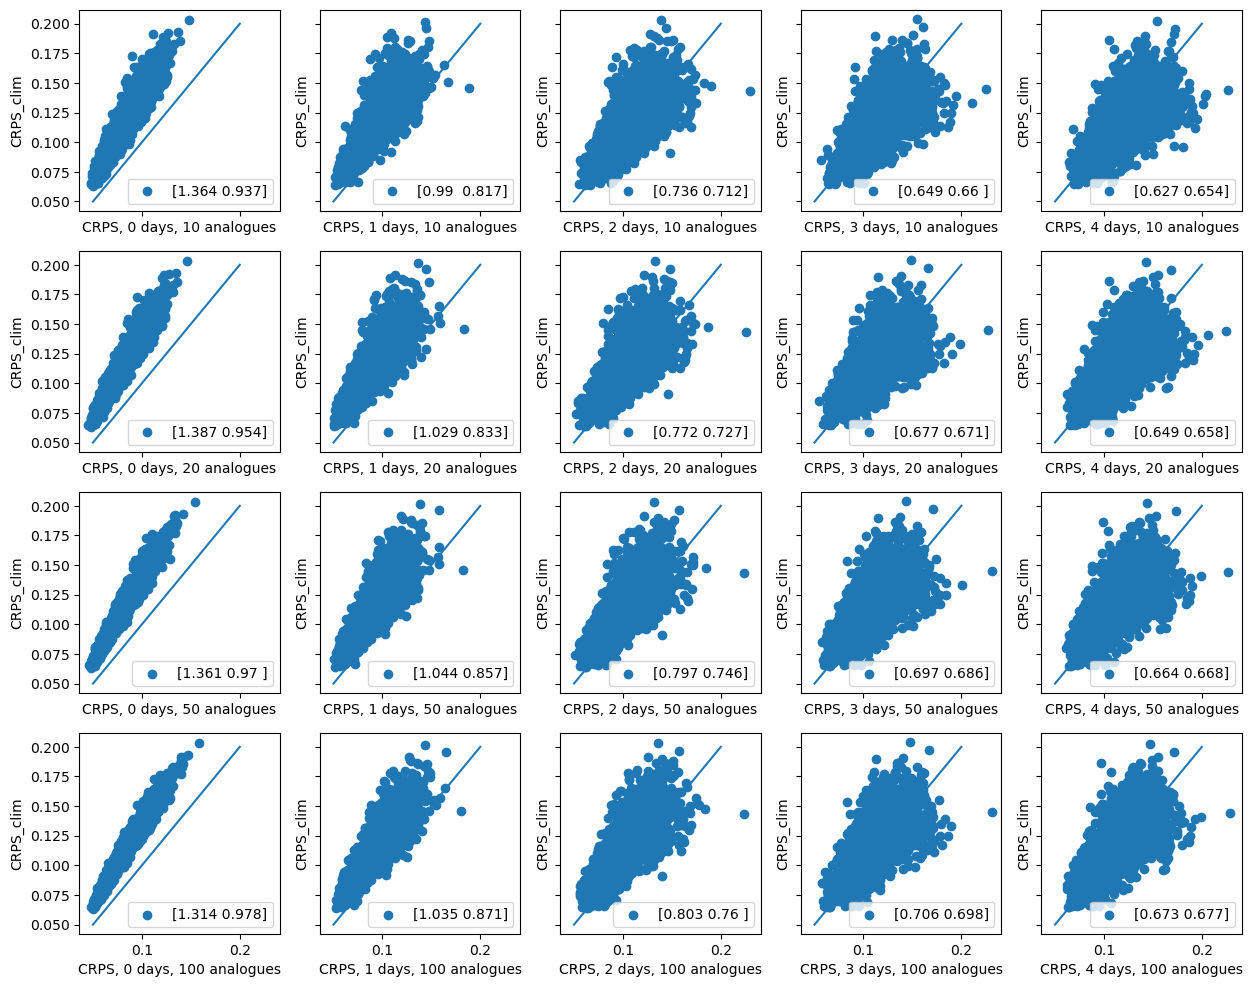

In [12]:
fig, axs = plt.subplots(len(Kvalues), len(horizons), figsize = (3*len(horizons), 3*len(Kvalues)), sharex = True, sharey = True)

for i, h in enumerate(horizons):
    for j, K in enumerate(Kvalues):
        x = CRPS_ana.sel(horizon = h, K = K)
        y = CRPS_clim.sel(horizon = h)
        reg = linregress(x, y)
        axs[j, i].scatter(x, y, label = np.round([reg.slope, reg.rvalue], 3))
        axs[j, i].legend()
        axs[j, i].plot([0.05, 0.2], [0.05, 0.2])
        axs[j, i].set_xlabel(f'CRPS, {h}, {K} analogues')
        axs[j, i].set_ylabel(f'CRPS_clim')

        #axs[j, i].hist(x - y, label = f'{np.round(np.array([np.mean(x - y), np.std(x - y)]), 3)}')

# Compute dimension

In [13]:
from dimension_functions import comp_d_mle, comp_d_pca, comp_d_ess

In [14]:
# find the analogues

# Choose maximum number of analogues
Kmax = 500
# Set subsampling in catalogue to avoid taking neighbours that are time-correlated
step_subsampling_catalogue = 2*7

# find analogues
dist, ind = find_analogues(pcs_norm, #ind_tar=ind_tar,
                           K=Kmax, step_subsampling_catalogue = step_subsampling_catalogue, )

In [15]:
dd_mle = comp_d_mle(pcs_norm, Kvalues, dist = dist, ind = ind)
dd_pca = comp_d_pca(pcs_norm, Kvalues, dist = dist, ind = ind)
dd_ess = comp_d_ess(pcs_norm, Kvalues, dist = dist, ind = ind)

d_mle, d_mle_smooth = dd_mle[0][ind_tar].T, dd_mle[1][ind_tar].T
d_pca, d_pca_smooth = dd_pca[0][ind_tar].T, dd_pca[1][ind_tar].T
d_ess, d_ess_smooth = dd_ess[0][ind_tar].T, dd_ess[1][ind_tar].T

d_mle = xr.DataArray(d_mle,
                     dims = ('K', 'initial_time'),
                     coords = {'K': Kvalues, 'initial_time': initial_time})

d_mle_smooth = xr.DataArray(d_mle_smooth,
                     dims = ('K', 'initial_time'),
                     coords = {'K': Kvalues, 'initial_time': initial_time})

d_pca = xr.DataArray(d_pca,
                     dims = ('K', 'initial_time'),
                     coords = {'K': Kvalues, 'initial_time': initial_time})

d_pca_smooth = xr.DataArray(d_pca_smooth,
                     dims = ('K', 'initial_time'),
                     coords = {'K': Kvalues, 'initial_time': initial_time})

d_ess = xr.DataArray(d_ess,
                     dims = ('K', 'initial_time'),
                     coords = {'K': Kvalues, 'initial_time': initial_time})

d_ess_smooth = xr.DataArray(d_ess_smooth,
                     dims = ('K', 'initial_time'),
                     coords = {'K': Kvalues, 'initial_time': initial_time})


4it [00:02,  1.72it/s]
4it [00:20,  5.10s/it]
4it [03:05, 46.32s/it]


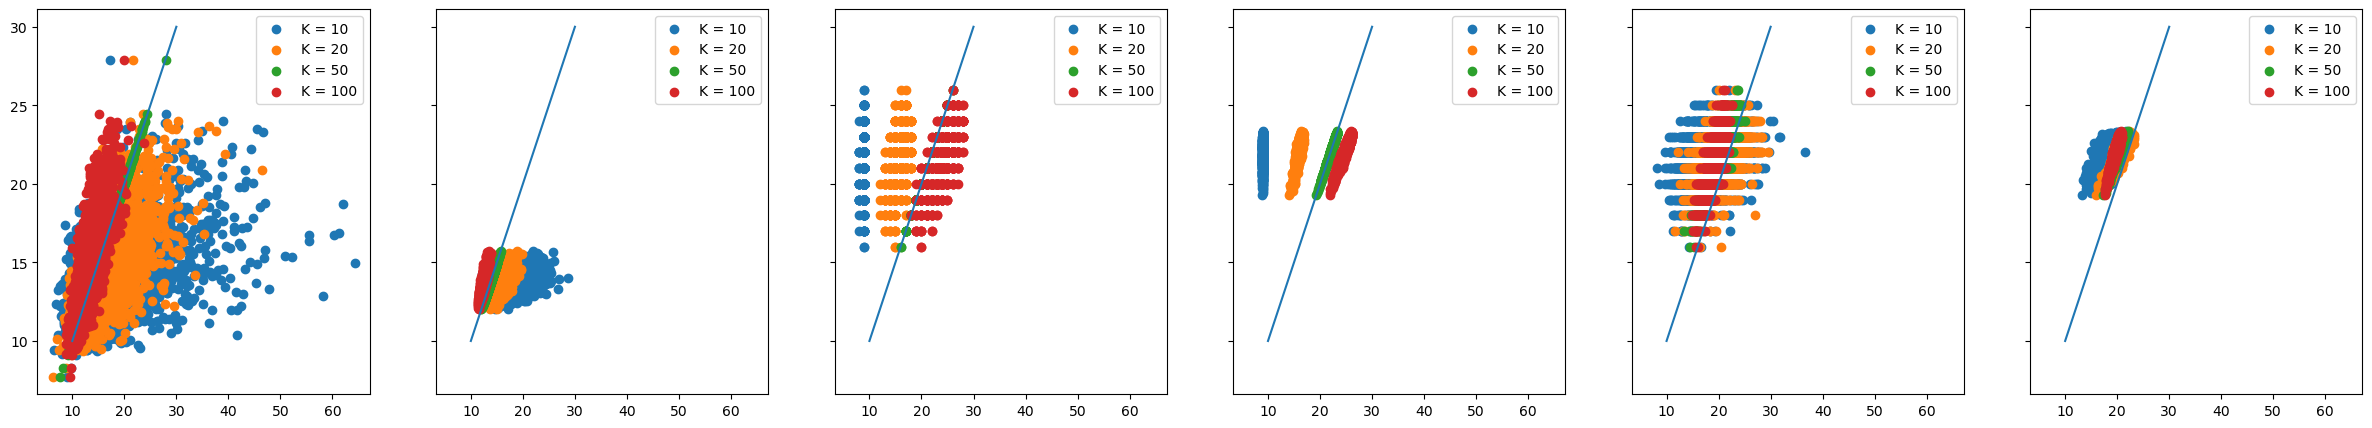

In [16]:
fig, axs = plt.subplots(1, 6, figsize = (30, 5), sharex = True, sharey = True)

for K in Kvalues:
    axs[0].scatter(d_mle.sel(K = K), d_mle.sel(K = 50), label = f'K = {K}')
    axs[1].scatter(d_mle_smooth.sel(K = K), d_mle_smooth.sel(K = 50), label = f'K = {K}')
    
    axs[2].scatter(d_pca.sel(K = K), d_pca.sel(K = 50), label = f'K = {K}')
    axs[3].scatter(d_pca_smooth.sel(K = K), d_pca_smooth.sel(K = 50), label = f'K = {K}')

    axs[4].scatter(d_ess.sel(K = K), d_pca.sel(K = 50), label = f'K = {K}')
    axs[5].scatter(d_ess_smooth.sel(K = K), d_pca_smooth.sel(K = 50), label = f'K = {K}')

axs[0].plot([10, 30], [10, 30])
axs[1].plot([10, 30], [10, 30])
axs[2].plot([10, 30], [10, 30])
axs[3].plot([10, 30], [10, 30])
axs[4].plot([10, 30], [10, 30])
axs[5].plot([10, 30], [10, 30])

axs[0].legend()
axs[1].legend()
axs[2].legend()
axs[3].legend()
axs[4].legend()
axs[5].legend()

# Link between dimension and predictability

In [161]:
correlations_d_mle = np.full((len(Kvalues), len(horizons)), np.nan)
correlations_d_mle_smooth = np.full((len(Kvalues), len(horizons)), np.nan)
correlations_d_pca = np.full((len(Kvalues), len(horizons)), np.nan)
correlations_d_pca_smooth = np.full((len(Kvalues), len(horizons)), np.nan)
correlations_d_ess = np.full((len(Kvalues), len(horizons)), np.nan)
correlations_d_ess_smooth = np.full((len(Kvalues), len(horizons)), np.nan)
for k, K in enumerate(Kvalues):
    for i, h in enumerate(horizons):

        x = CRPS_ana.isel(horizon = i, K = k) - CRPS_clim.isel(horizon = i)
        
        correlations_d_mle[k, i] = np.corrcoef(x, d_mle.isel(K = k))[0, 1]
        correlations_d_mle_smooth[k, i] = np.corrcoef(x, d_mle_smooth.isel(K = k))[0, 1]
        correlations_d_pca[k, i] = np.corrcoef(x, d_pca.isel(K = k))[0, 1]
        correlations_d_pca_smooth[k, i] = np.corrcoef(x, d_pca_smooth.isel(K = k))[0, 1]
        correlations_d_ess[k, i] = np.corrcoef(x, d_ess.isel(K = k))[0, 1]
        correlations_d_ess_smooth[k, i] = np.corrcoef(x, d_ess_smooth.isel(K = k))[0, 1]

correlations_d_mle = xr.DataArray(correlations_d_mle, dims = ('K', 'horizon'), coords = {'K': Kvalues, 'horizon': horizons})
correlations_d_mle_smooth = xr.DataArray(correlations_d_mle_smooth, dims = ('K', 'horizon'), coords = {'K': Kvalues, 'horizon': horizons})
correlations_d_pca = xr.DataArray(correlations_d_pca, dims = ('K', 'horizon'), coords = {'K': Kvalues, 'horizon': horizons})
correlations_d_pca_smooth = xr.DataArray(correlations_d_pca_smooth, dims = ('K', 'horizon'), coords = {'K': Kvalues, 'horizon': horizons})
correlations_d_ess = xr.DataArray(correlations_d_ess, dims = ('K', 'horizon'), coords = {'K': Kvalues, 'horizon': horizons})
correlations_d_ess_smooth = xr.DataArray(correlations_d_ess_smooth, dims = ('K', 'horizon'), coords = {'K': Kvalues, 'horizon': horizons})

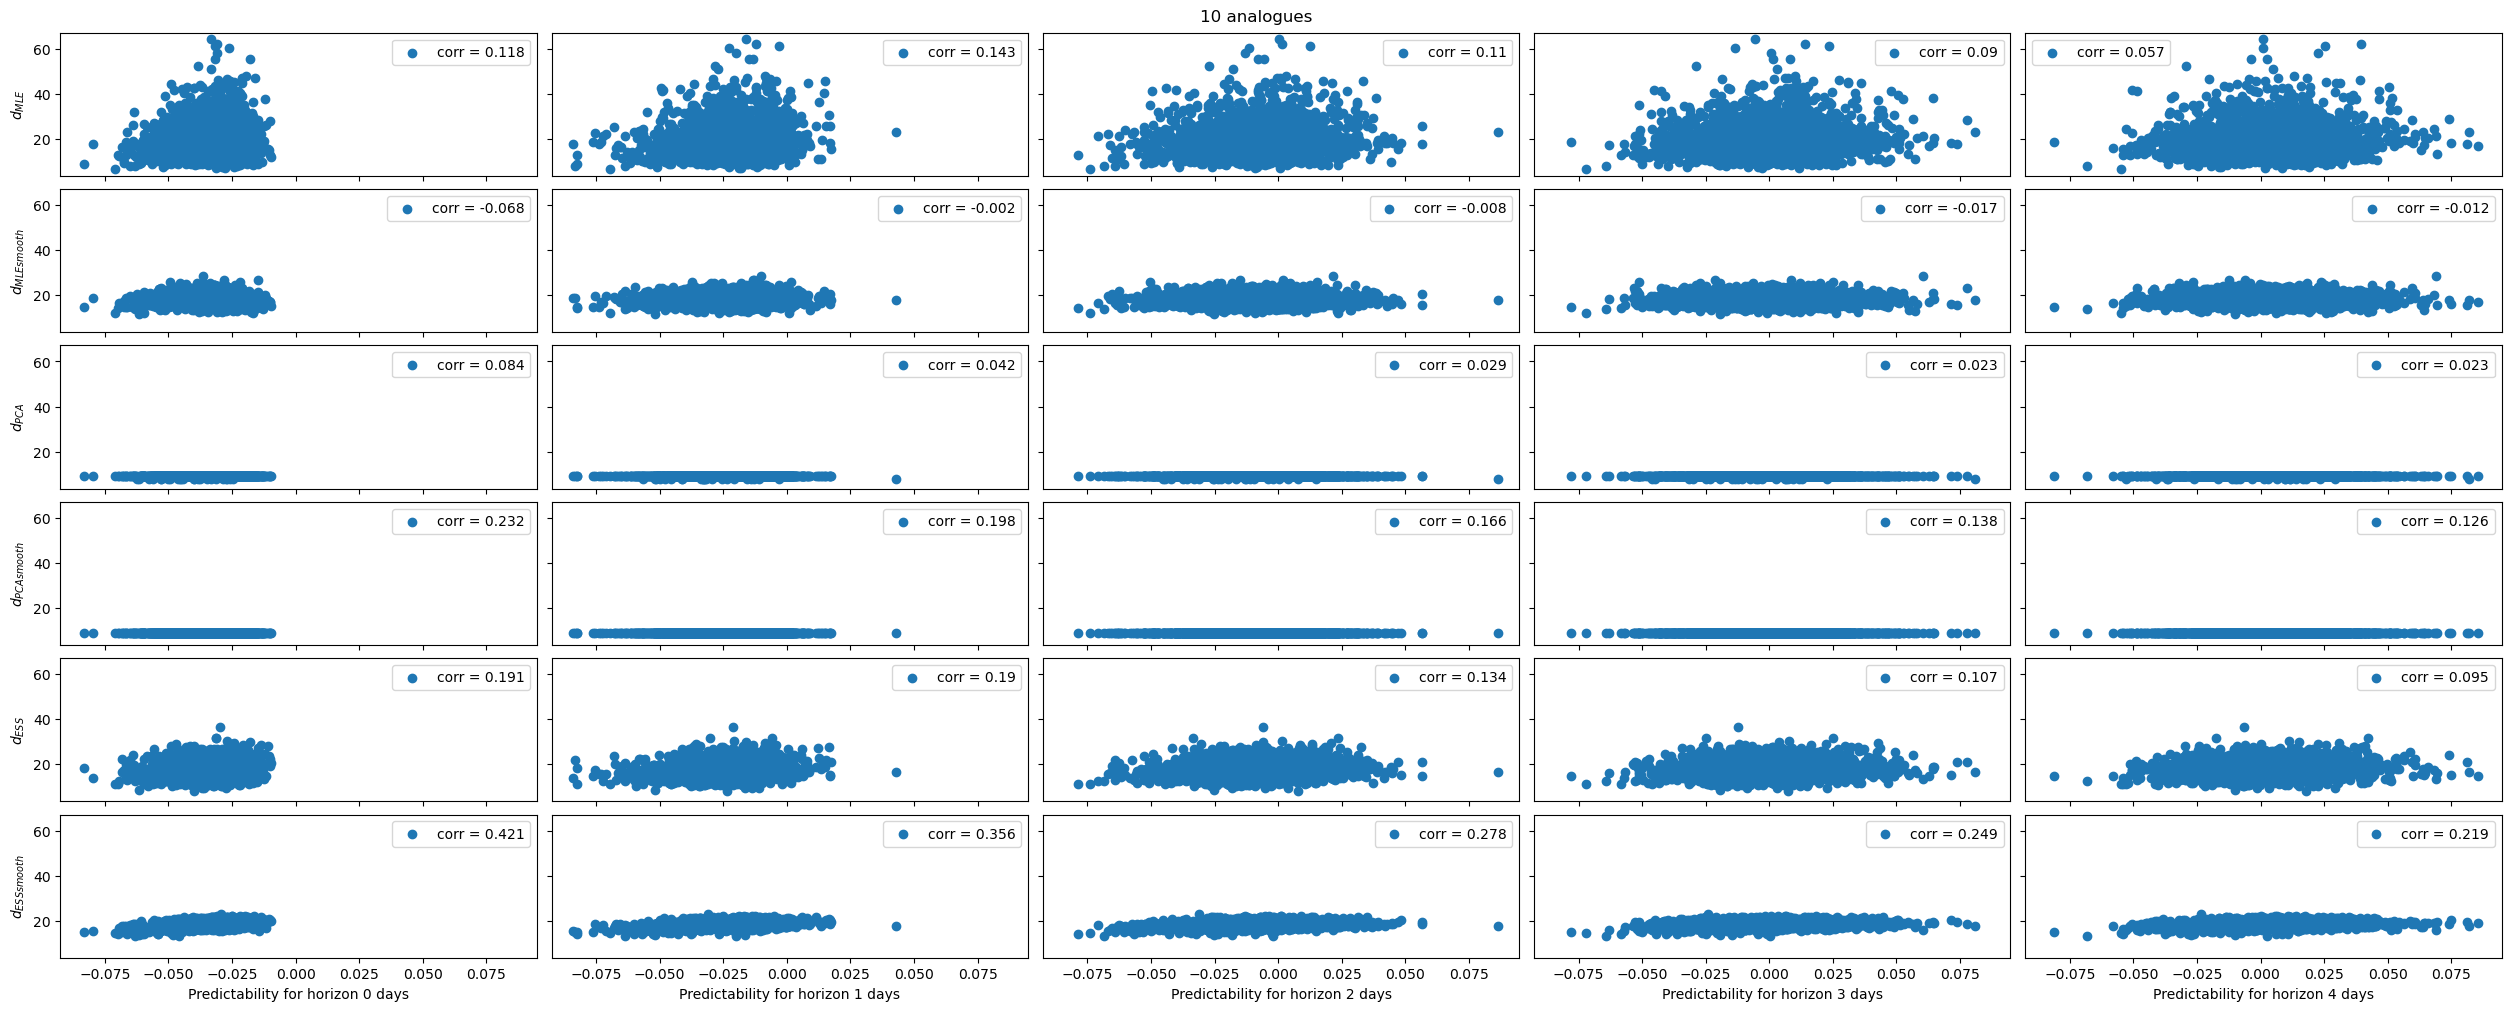

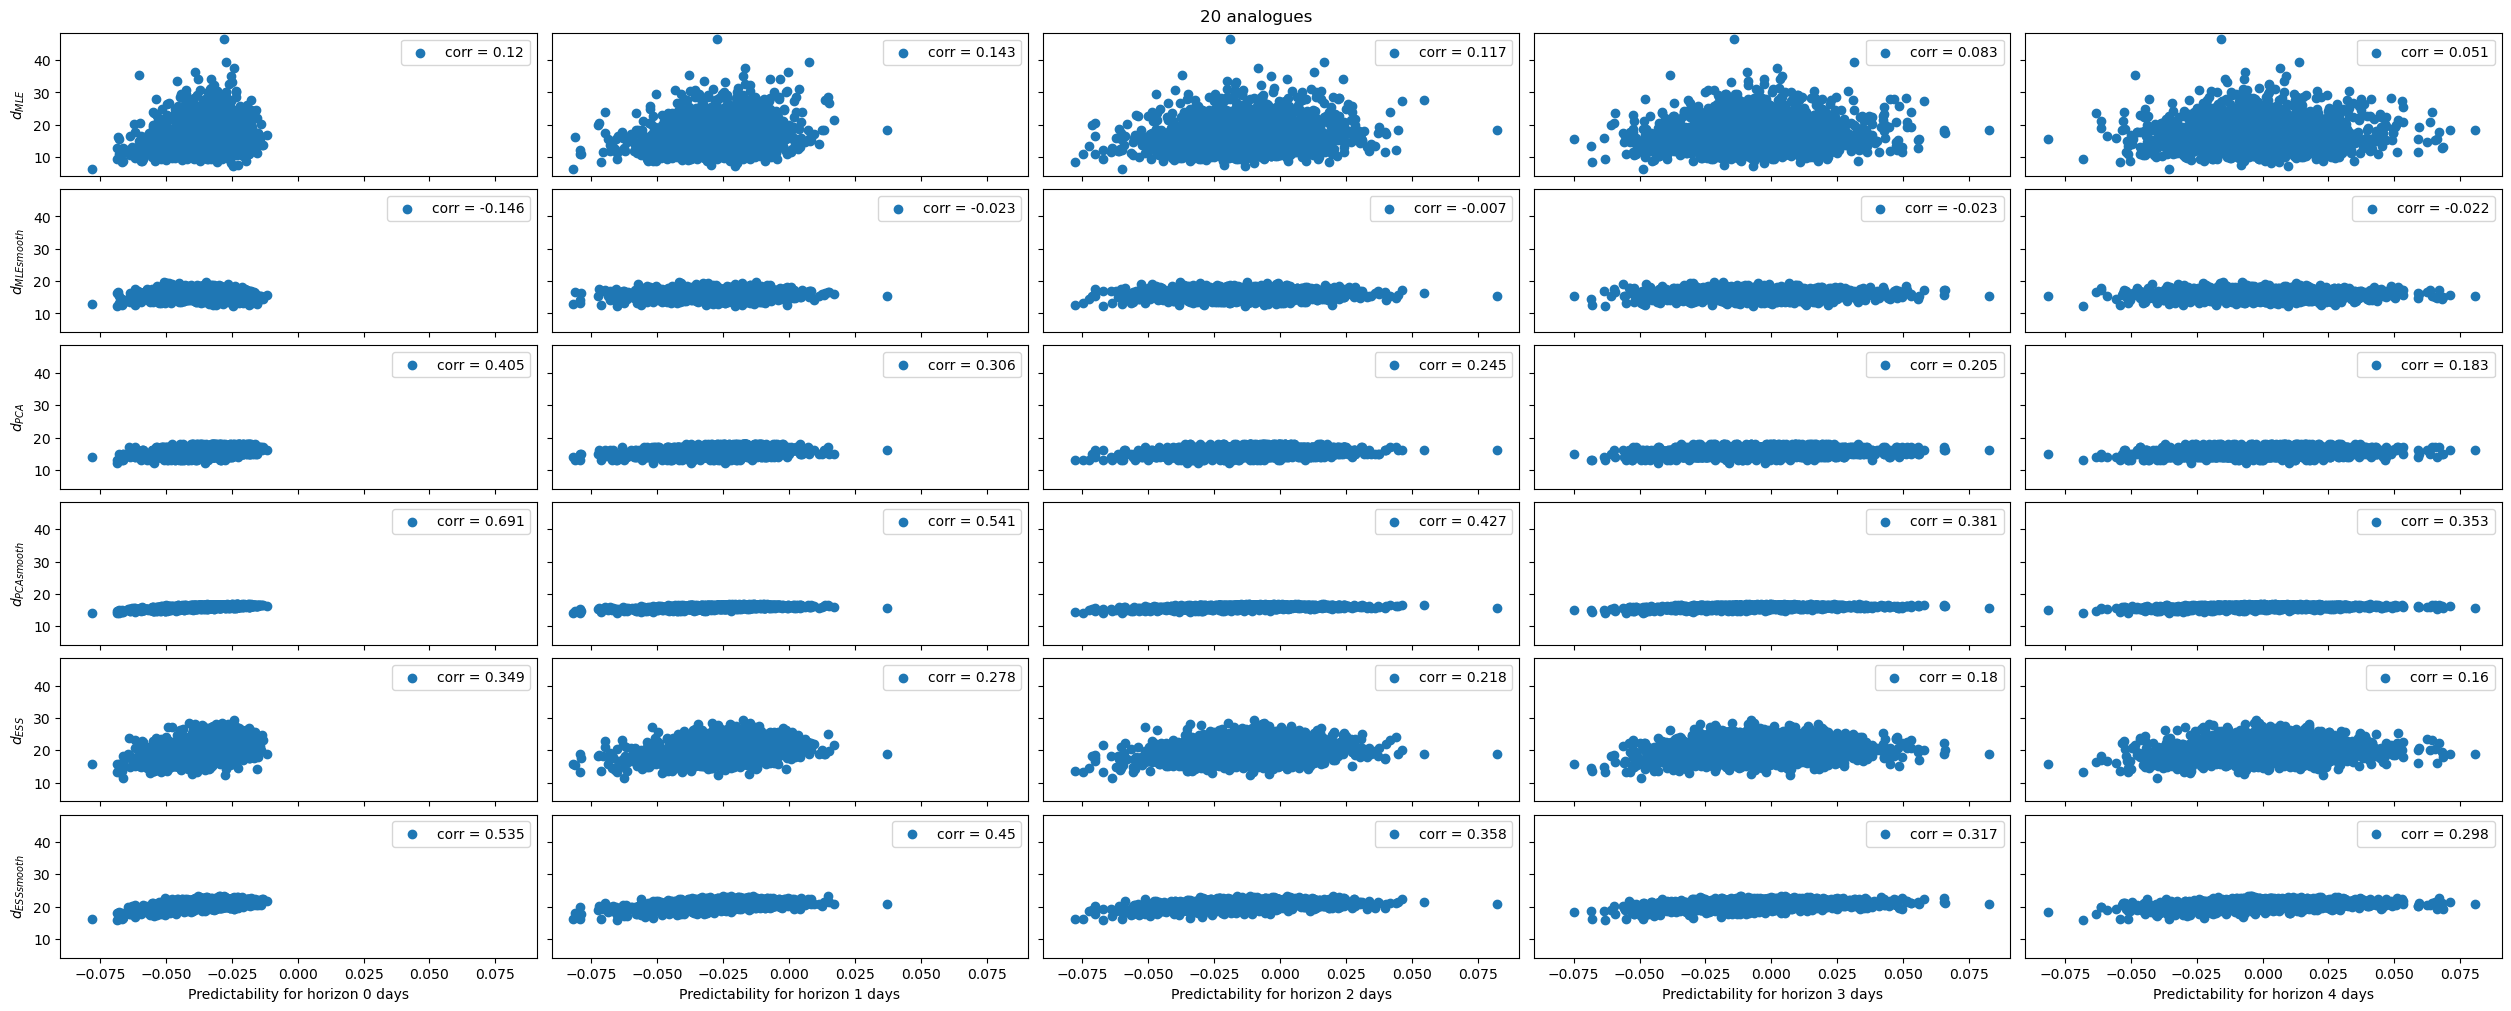

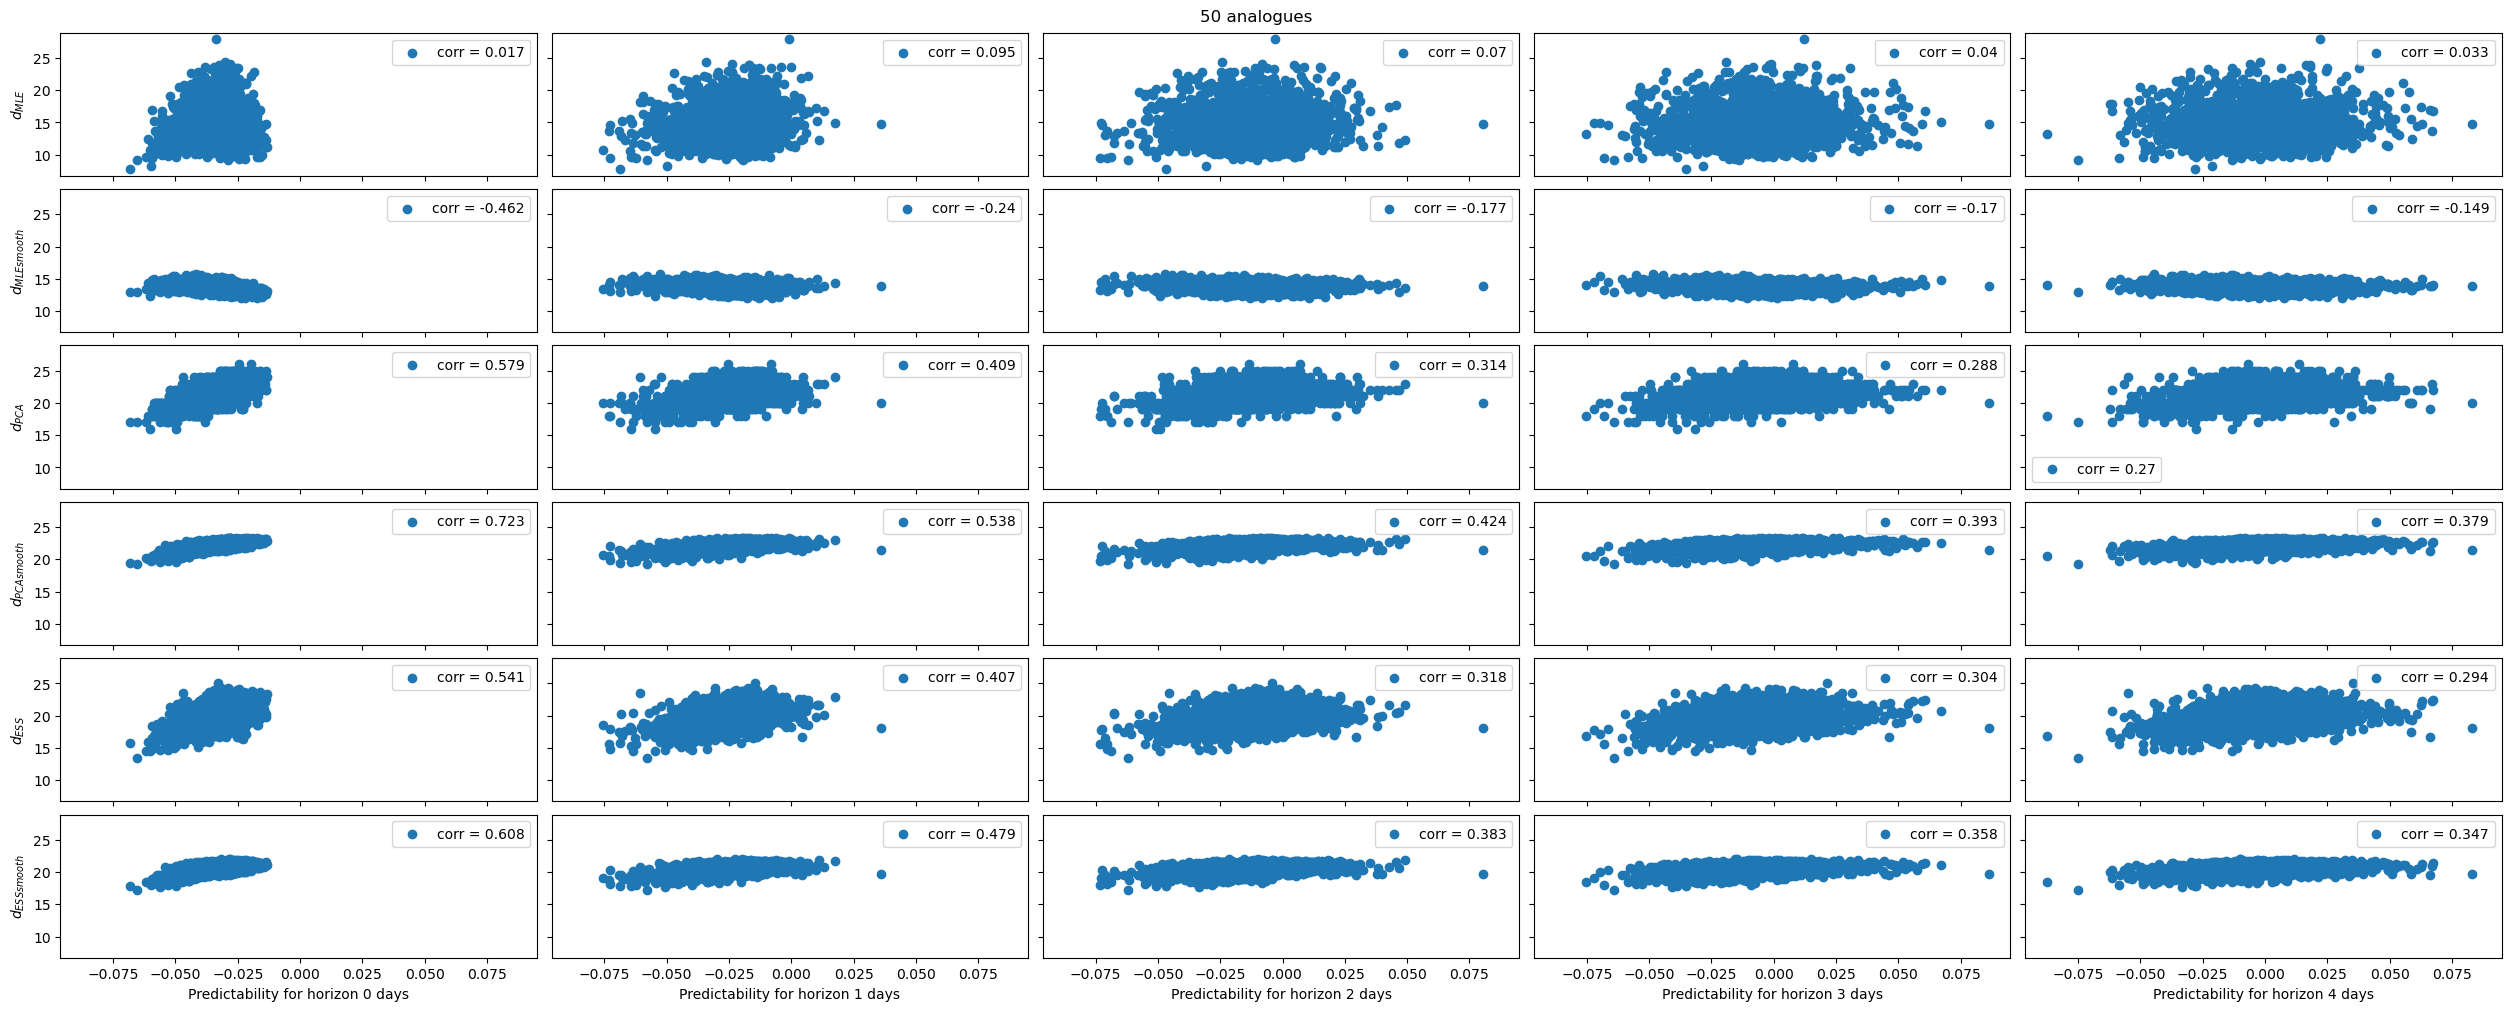

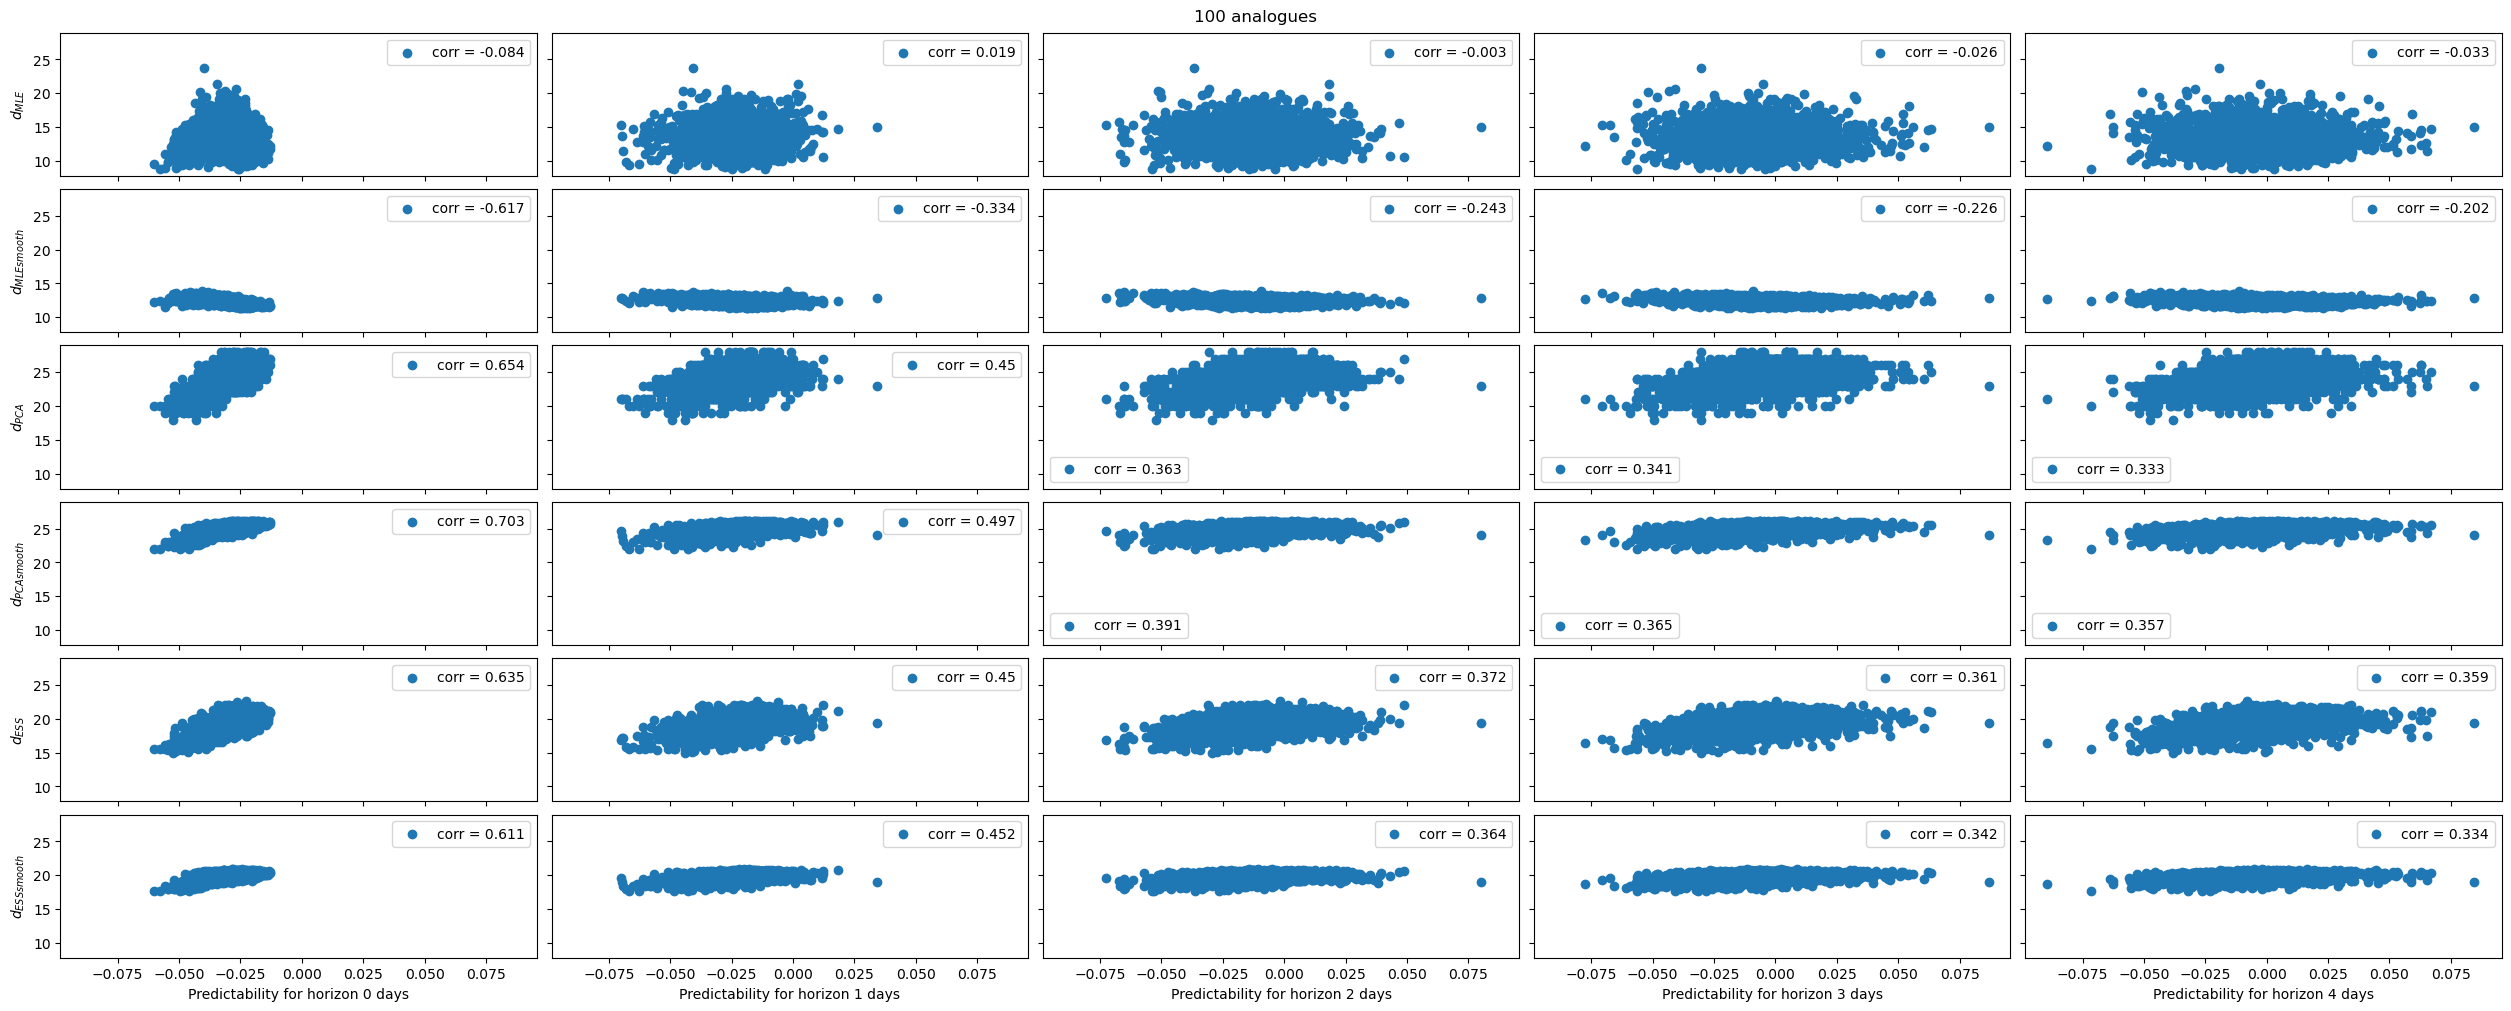

In [162]:
for K in Kvalues:

    fig, axs = plt.subplots(6, len(horizons), figsize = (25, 10), constrained_layout = True, sharex = True, sharey = True)

    fig.suptitle(f'{K} analogues')

    
    axs[0, 0].set_ylabel('$d_{MLE}$')
    axs[1, 0].set_ylabel('$d_{MLE smooth}$')
    axs[2, 0].set_ylabel('$d_{PCA}$')
    axs[3, 0].set_ylabel('$d_{PCA smooth}$')
    axs[4, 0].set_ylabel('$d_{ESS}$')
    axs[5, 0].set_ylabel('$d_{ESS smooth}$')
    
    for i, h in enumerate(horizons):
        
        x = CRPS_ana.sel(horizon = h, K = K) - CRPS_clim.sel(horizon = h)
        
        y = d_mle.sel(K = K)
        axs[0, i].scatter(x, y, label = f'corr = {np.round(np.corrcoef(x, y)[0, 1], 3)}')
        axs[0, i].legend()

        y = d_mle_smooth.sel(K = K)
        axs[1, i].scatter(x, y, label = f'corr = {np.round(np.corrcoef(x, y)[0, 1], 3)}')
        axs[1, i].legend()

        y = d_pca.sel(K = K)
        axs[2, i].scatter(x, y, label = f'corr = {np.round(np.corrcoef(x, y)[0, 1], 3)}')
        axs[2, i].legend()
    
        y = d_pca_smooth.sel(K = K)
        axs[3, i].scatter(x, y, label = f'corr = {np.round(np.corrcoef(x, y)[0, 1], 3)}')
        axs[3, i].legend()

        y = d_ess.sel(K = K)
        axs[4, i].scatter(x, y, label = f'corr = {np.round(np.corrcoef(x, y)[0, 1], 3)}')
        axs[4, i].legend()

        y = d_ess_smooth.sel(K = K)
        axs[5, i].scatter(x, y, label = f'corr = {np.round(np.corrcoef(x, y)[0, 1], 3)}')
        axs[5, i].legend()
        
        
        axs[-1, i].set_xlabel(f'Predictability for horizon {h}')
        
    plt.show()

# Present the results

the conclusions of the above plots seem to be:
 - $d_{MLE}$ has no correlation with the predictability (negative correlation for $d_{MLE, smooth}$)
 - the correlation decreases with the horizon
 - Above 20 analogues, the correlation between predictability and the dimension does not change anymore
 - $d_{ESS}$ seems better with 10 analogues, but $d_{PCA}$ is better otherwise

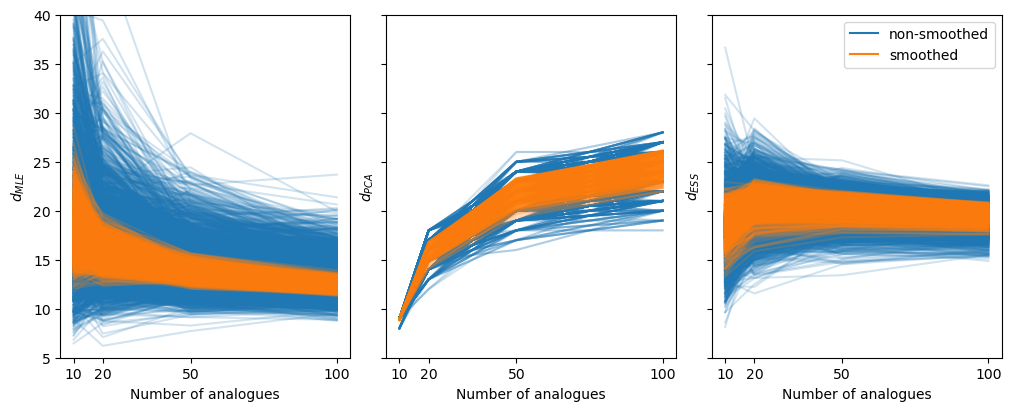

In [163]:
fig, axs = plt.subplots(1, 3, figsize = (10, 4), constrained_layout = True, sharey = True)

axs[0].plot(d_mle.K, d_mle.data, c = 'C0', alpha = 0.2)
axs[0].plot(d_mle_smooth.K, d_mle_smooth.data, c = 'C1', alpha = 0.2)
axs[0].set_ylim(5, 40)
axs[0].set_xticks(Kvalues)
axs[0].set_ylabel('$d_{MLE}$')

axs[1].plot(d_pca.K, d_pca.data, c = 'C0', alpha = 0.2)
axs[1].plot(d_pca_smooth.K, d_pca_smooth.data, c = 'C1', alpha = 0.2)
axs[1].set_xticks(Kvalues)
axs[1].set_ylabel('$d_{PCA}$')

axs[2].plot(d_ess.K, d_ess.data, c = 'C0', alpha = 0.2)
axs[2].plot(d_ess_smooth.K, d_ess_smooth.data, c = 'C1', alpha = 0.2)
axs[2].set_xticks(Kvalues)
axs[2].set_ylabel('$d_{ESS}$')

axs[2].plot([], [], c = 'C0', label = 'non-smoothed')
axs[2].plot([], [], c = 'C1', label = 'smoothed')

axs[2].legend()

for ax in axs:
    ax.set_xlabel('Number of analogues')

plt.savefig('analogues_convergence.png')

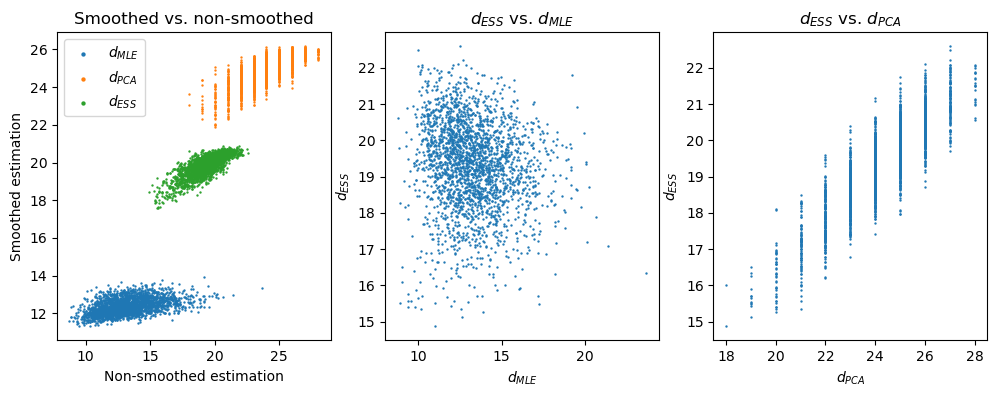

In [164]:
fig, axs = plt.subplots(1, 3, figsize = (12, 4))

axs[0].scatter(d_mle.sel(K = K), d_mle_smooth.sel(K = K), s = 0.5, label = '$d_{MLE}$')
axs[0].scatter(d_pca.sel(K = K), d_pca_smooth.sel(K = K), s = 0.5, label = '$d_{PCA}$')
axs[0].scatter(d_ess.sel(K = K), d_ess_smooth.sel(K = K), s = 0.5, label = '$d_{ESS}$')
axs[0].legend(markerscale = 3.)

axs[0].set_xlabel('Non-smoothed estimation')
axs[0].set_ylabel('Smoothed estimation')
axs[0].set_title('Smoothed vs. non-smoothed')

axs[1].scatter(d_mle.sel(K = K), d_ess.sel(K = K), s = 0.5)
axs[1].set_xlabel('$d_{MLE}$')
axs[1].set_ylabel('$d_{ESS}$')
axs[1].set_title('$d_{ESS}$ vs. $d_{MLE}$')

axs[2].scatter(d_pca.sel(K = K), d_ess.sel(K = K), s = 0.5)
axs[2].set_xlabel('$d_{PCA}$')
axs[2].set_ylabel('$d_{ESS}$')
axs[2].sharey(axs[1])
axs[2].set_title('$d_{ESS}$ vs. $d_{PCA}$')

plt.savefig('estimators_comparison.png')

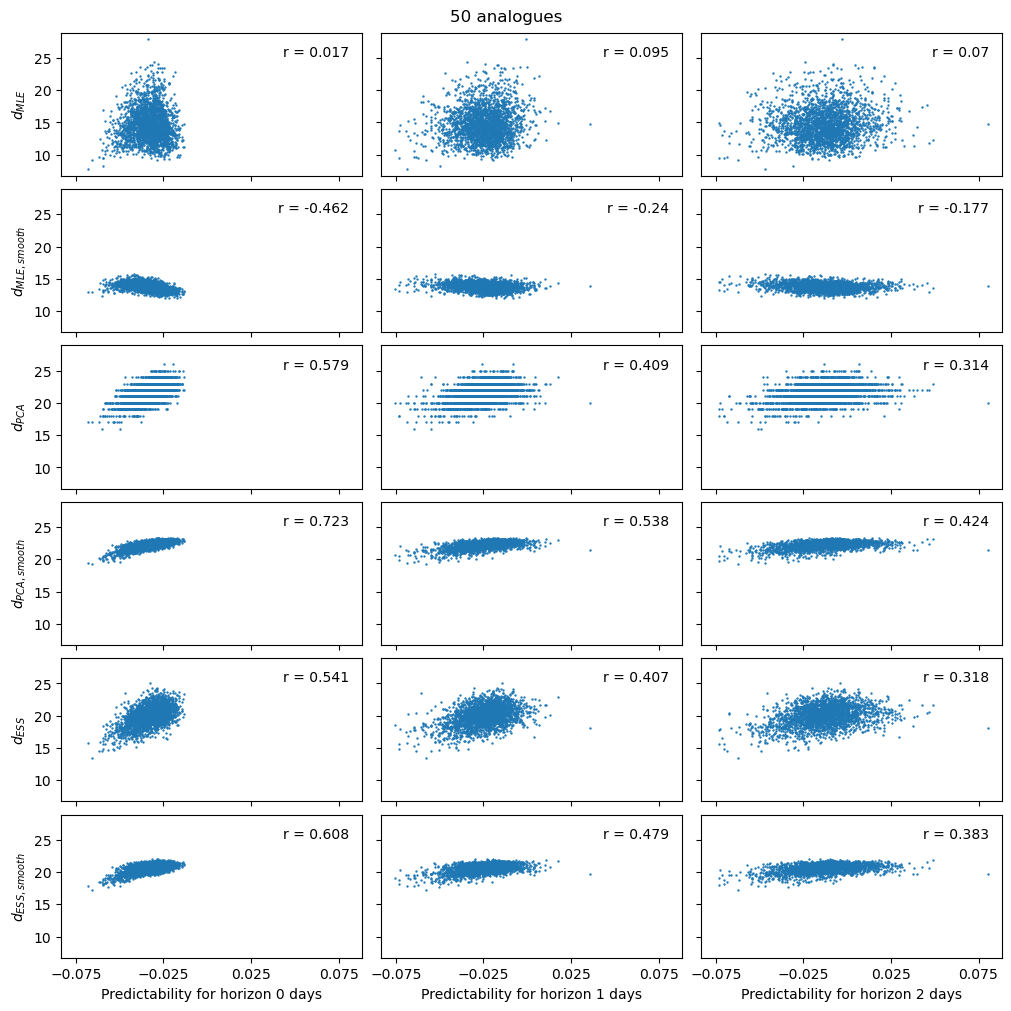

In [165]:
K = 50

fig, axs = plt.subplots(6, len(horizons[:3]), figsize = (10, 10), constrained_layout = True, sharex = True, sharey = True)

fig.suptitle(f'{K} analogues')


axs[0, 0].set_ylabel('$d_{MLE}$')
axs[1, 0].set_ylabel('$d_{MLE, smooth}$')
axs[2, 0].set_ylabel('$d_{PCA}$')
axs[3, 0].set_ylabel('$d_{PCA, smooth}$')
axs[4, 0].set_ylabel('$d_{ESS}$')
axs[5, 0].set_ylabel('$d_{ESS, smooth}$')

for i, h in enumerate(horizons[:3]):
    
    x = CRPS_ana.sel(horizon = h, K = K) - CRPS_clim.sel(horizon = h)
    
    y = d_mle.sel(K = K)
    axs[0, i].scatter(x, y, label = f'r = {np.round(np.corrcoef(x, y)[0, 1], 3)}', s = 0.5)
    axs[0, i].legend(frameon = False, markerscale = 0., loc = 'upper right')

    y = d_mle_smooth.sel(K = K)
    axs[1, i].scatter(x, y, label = f'r = {np.round(np.corrcoef(x, y)[0, 1], 3)}', s = 0.5)
    axs[1, i].legend(frameon = False, markerscale = 0., loc = 'upper right')

    y = d_pca.sel(K = K)
    axs[2, i].scatter(x, y, label = f'r = {np.round(np.corrcoef(x, y)[0, 1], 3)}', s = 0.5)
    axs[2, i].legend(frameon = False, markerscale = 0., loc = 'upper right')

    y = d_pca_smooth.sel(K = K)
    axs[3, i].scatter(x, y, label = f'r = {np.round(np.corrcoef(x, y)[0, 1], 3)}', s = 0.5)
    axs[3, i].legend(frameon = False, markerscale = 0., loc = 'upper right')

    y = d_ess.sel(K = K)
    axs[4, i].scatter(x, y, label = f'r = {np.round(np.corrcoef(x, y)[0, 1], 3)}', s = 0.5)
    axs[4, i].legend(frameon = False, markerscale = 0., loc = 'upper right')

    y = d_ess_smooth.sel(K = K)
    axs[5, i].scatter(x, y, label = f'r = {np.round(np.corrcoef(x, y)[0, 1], 3)}', s = 0.5)
    axs[5, i].legend(frameon = False, markerscale = 0., loc = 'upper right')
    
    
    axs[-1, i].set_xlabel(f'Predictability for horizon {h}')
    axs[-1, i].set_xticks([-0.075, -0.025, 0.025, 0.075])

plt.savefig('predictability_dimensions_ERA5_50.png')

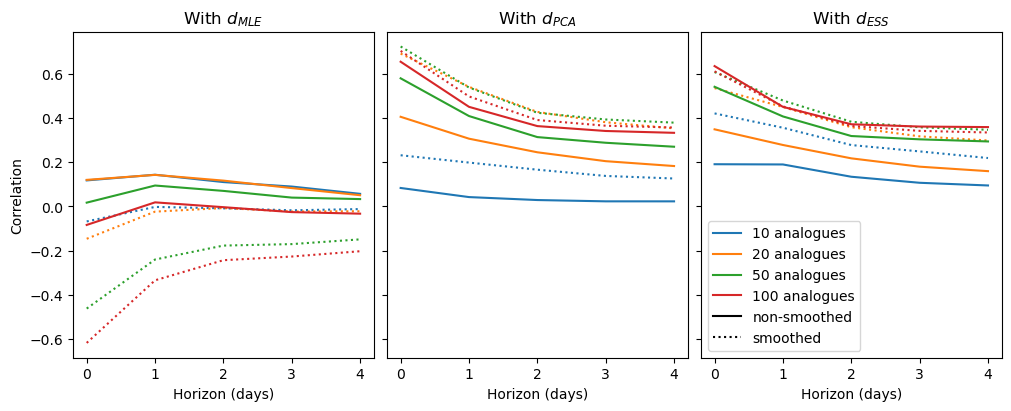

In [166]:
fig, axs = plt.subplots(1, 3, figsize = (10, 4), sharey = True, constrained_layout = True)

for k, K in enumerate(Kvalues):
    axs[0].plot(horizons, correlations_d_mle.isel(K = k), c = f'C{k}')
    axs[0].plot(horizons, correlations_d_mle_smooth.isel(K = k), linestyle = 'dotted', c = f'C{k}')

    axs[1].plot(horizons, correlations_d_pca.isel(K = k), c = f'C{k}')
    axs[1].plot(horizons, correlations_d_pca_smooth.isel(K = k), linestyle = 'dotted', c = f'C{k}')
    
    axs[2].plot(horizons, correlations_d_ess.isel(K = k), c = f'C{k}')
    axs[2].plot(horizons, correlations_d_ess_smooth.isel(K = k), linestyle = 'dotted', c = f'C{k}')

    axs[2].plot([], [], c = f'C{k}', label = f'{K} analogues')
axs[2].plot([], [], c = 'black', label = 'non-smoothed')
axs[2].plot([], [], c = 'black', label = 'smoothed', linestyle = 'dotted')
    
axs[2].legend()

axs[0].set_xlabel('Horizon (days)')
axs[1].set_xlabel('Horizon (days)')
axs[2].set_xlabel('Horizon (days)')
axs[0].set_title('With $d_{MLE}$')
axs[1].set_title('With $d_{PCA}$')
axs[2].set_title('With $d_{ESS}$')

axs[0].set_ylabel('Correlation')

plt.savefig('correlation_predictability_dimension_ERA5.png')

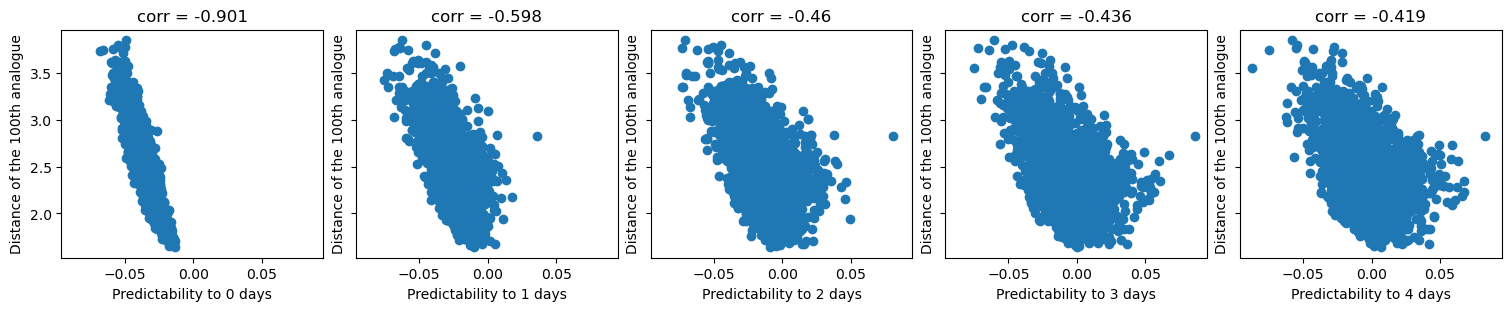

In [156]:
K = 50

fig, axs = plt.subplots(1, len(horizons), figsize = (15, 3), constrained_layout = True, sharex = True, sharey = True)

for i, h in enumerate(horizons):
    
    x = CRPS_ana.sel(horizon = h, K = K) - CRPS_clim.sel(horizon = h)
    y = dist[ind_tar][:, 100]
    
    axs[i].scatter(x, y)
    axs[i].set_title(f'corr = {np.round(np.corrcoef(x, y)[0, 1], 3)}')
    axs[i].set_xlabel(f'Predictability to {h}')
    axs[i].set_ylabel('Distance of the 100th analogue')

it seems that there is a very strong correlation of our predictability proxy with the distances of the analogues. This seems natural, since points with analogues very far away will likely have different dynamics. This shows maybe that our measure of predictability is not very adequate. 

 - What is the advantage of considering the dimension instead of a metric like the distance to the 100th analogue ?
 - It appears also that, if I consider the ratio of CRPSs as proxy for the predictability, the results change: the link between predictability and the different dimensions chnage ($d_{mle}$ is not the worse anymore!), and the link between the distance of the 100th analogue and the predictability also changes